In [5]:
# Install PyCaret (run once)
#!pip install pycaret

import pandas as pd
from sklearn.datasets import fetch_california_housing

# Load dataset into a DataFrame
data_raw = fetch_california_housing(as_frame=True)
df = data_raw.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
from pycaret.regression import *

# Initialize the PyCaret environment
# target = column we want to predict
reg = setup(
    data=df,
    target='MedHouseVal',
    session_id=42,           # for reproducibility
    verbose=False
)

In [7]:
# Compare all available models and pick the best one
best_model = compare_models()

# This prints a leaderboard sorted by R² (higher = better)
# best_model is automatically the top performer

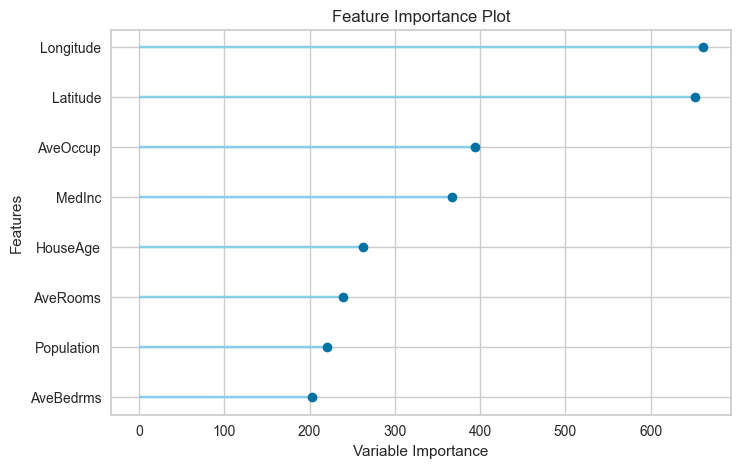

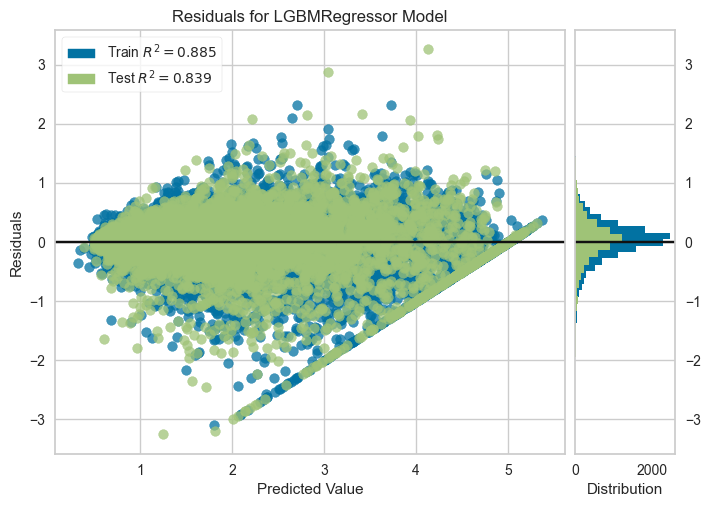

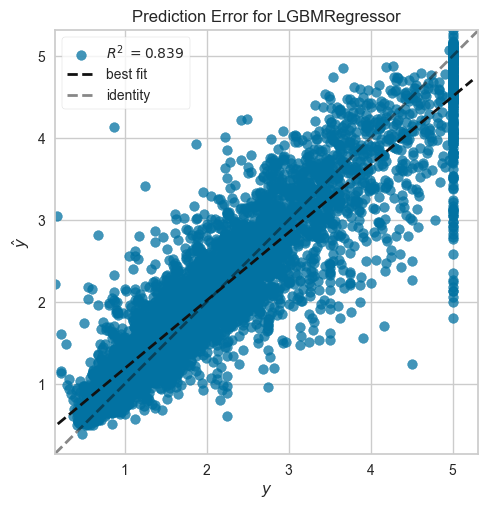

In [8]:
# Feature importance — which inputs matter most?
plot_model(best_model, plot='feature')

# Residuals — are errors random (good) or patterned (bad)?
plot_model(best_model, plot='residuals')

# Predicted vs Actual values
plot_model(best_model, plot='error')

In [9]:
# Predict on the held-out test set (automatically created during setup)
predictions = predict_model(best_model)

# predictions has a new column 'prediction_label' with the estimated house value
predictions[['MedHouseVal', 'prediction_label']].head(10)

# To predict on completely new data:
# new_data = pd.DataFrame({...})  ← your new rows, no target column needed
# predict_model(best_model, data=new_data)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,0.3097,0.2119,0.4603,0.8385,0.1410,0.1795


,MedHouseVal,prediction_label
20046,0.47700,0.609230
3024,0.45800,1.039423
15663,5.00001,4.911966
20484,2.18600,2.551484
9814,2.78000,2.457485
13311,1.58700,1.754659
7113,1.98200,2.391092
7668,1.57500,1.613881
18246,3.40000,2.916633
5723,4.46600,4.710172


In [10]:
# Save model to disk as a .pkl file
save_model(best_model, 'california_housing_model')

# Load it back later with:
# loaded_model = load_model('california_housing_model')
# predict_model(loaded_model, data=new_data)

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['MedInc', 'HouseAge', 'AveRooms',
                                              'AveBedrms', 'Population',
                                              'AveOccup', 'Latitude',
                                              'Longitude'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=[],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('trained_model', LGBMRegressor(n_jobs=-1, random_state=42))]),
 'california_housing_model.pkl')